# MAPAS TEMÁTICOS

In [ ]:
import geopandas as gpd
import pandas as pd

# links
linkGit = 'https://raw.githubusercontent.com/Melanie2649-ai/Plantilla/main/'
linkUru = 'uruguay.gpkg'
linkData = 'POBLACI%C3%93N%20DE%20URUGUAY.csv'

# leer mapa
mapa = gpd.read_file(linkGit + linkUru)

# corregir tildes
mapa["shapeName"] = mapa["shapeName"].str.encode("latin1").str.decode("utf-8")

# leer datos
data = pd.read_csv(linkGit + linkData)

In [ ]:
# merge limpio
mapa = mapa.merge(
    data[["Departamento", "Población"]],
    left_on="shapeName",
    right_on="Departamento"
)


<Axes: >

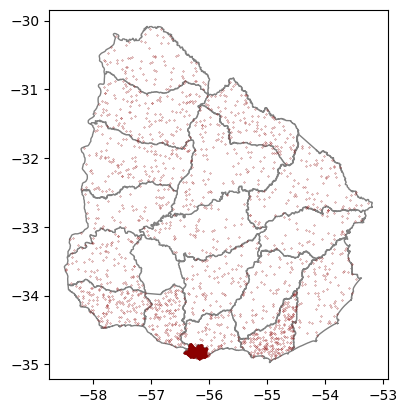

In [ ]:
# DDM
dot_value = 1000
mapa["num_puntos"] = (mapa["Población"] / dot_value).astype(int).clip(lower=1)

dots = mapa.sample_points(size=mapa["num_puntos"]).explode(index_parts=True)
dots = dots.reset_index(drop=True)
dots_gdf = gpd.GeoDataFrame(geometry=dots, crs=mapa.crs)

base = mapa.plot(facecolor="white", edgecolor="grey")
dots_gdf.plot(ax=base, color="darkred", markersize=0.05)

In [ ]:
# copiar mapa
mapa_psm = mapa.copy()

# usar centroides (centro de cada departamento)
mapa_psm["geometry"] = mapa_psm.geometry.centroid

# tamaño proporcional
mapa_psm["size"] = mapa_psm["Población"]**0.5 / 30

/tmp/ipykernel_3921/1761237269.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  mapa_psm["geometry"] = mapa_psm.geometry.centroid


<Axes: >

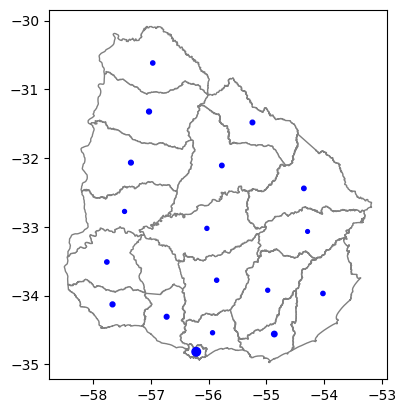

In [ ]:
base = mapa.plot(facecolor="white", edgecolor="grey")

mapa_psm.plot(
    ax=base,
    markersize=mapa_psm["size"],
    color="blue",
    alpha=1
)

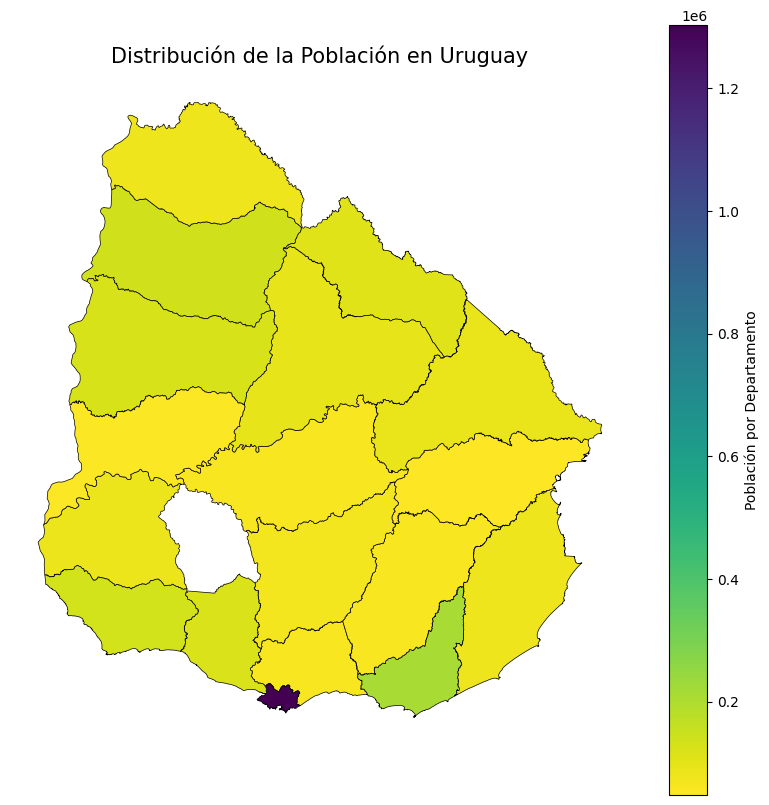

In [ ]:
import matplotlib.pyplot as plt

columna_datos = "Población"
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

mapa.plot(column=columna_datos,
          cmap='viridis_r',
          legend=True,
          legend_kwds={'label': "Población por Departamento",
                       'orientation': "vertical"},
          edgecolor='black',
          linewidth=0.5,     # Grosor de los bordes
          ax=ax)

ax.set_title('Distribución de la Población en Uruguay', fontsize=15)
ax.axis('off')
plt.show()

In [ ]:
# guardar en geopackage

# 1. base (coropleta incluida)
mapa.to_file("uruguay_maps.gpkg", layer="uruguay_base", driver="GPKG")

# 2. DDM (puntos)
dots_gdf.to_file("uruguay_maps.gpkg", layer="uruguay_ddm", driver="GPKG")

# 3. PSM (centroides)
mapa_psm.to_file("uruguay_maps.gpkg", layer="uruguay_psm", driver="GPKG")